
# Intelligent Phishing Website Detection Using Machine Learning

# Part 5 – Explainable AI, Risk Score & Deployment Pipeline

This notebook covers:

1. Load Optimized Model
2. SHAP Explainability
3. Feature Importance
4. Risk Score Generation
5. Human Readable Reasons
6. Deployment Ready Prediction Function
7. Save Pipeline
8. Test on Sample URLs


In [1]:

import warnings
warnings.filterwarnings("ignore")

import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report


In [2]:

# Load Dataset
df=pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

TARGET='label'

X=df.drop(columns=[TARGET])

non_numeric_cols = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
cols_to_drop = [col for col in non_numeric_cols if col in X.columns]
X = X.drop(columns=cols_to_drop)

y=df[TARGET]


In [3]:

# Load Model
model=joblib.load("optimized_phishing_model.pkl")
preprocessor=joblib.load("preprocessor.pkl")

print(model)


RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42)


## SHAP Explainability

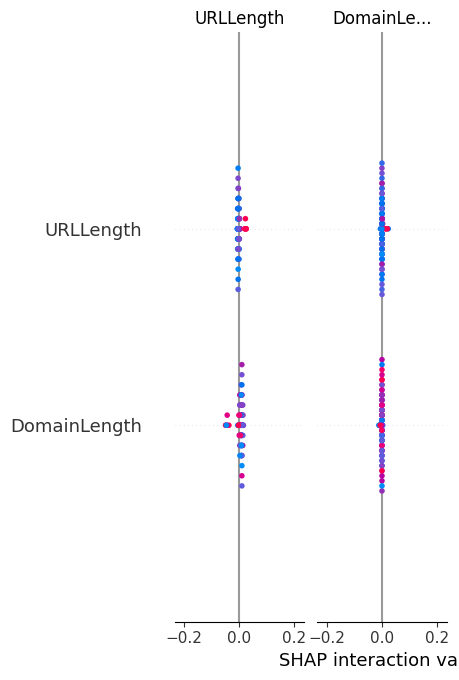

In [4]:

explainer=shap.TreeExplainer(model)

sample_raw=X.iloc[:100]
sample=pd.DataFrame(preprocessor.transform(sample_raw), columns=X.columns)

shap_values=explainer.shap_values(sample)

shap.summary_plot(
shap_values,
sample,
show=False
)

plt.show()


## Global Feature Importance

,Feature,Importance
49,NoOfExternalRef,0.186146
22,LineOfCode,0.159527
3,URLSimilarityIndex,0.146485
47,NoOfSelfRef,0.113483
44,NoOfImage,0.095023
46,NoOfJS,0.078101
45,NoOfCSS,0.032542
32,HasDescription,0.032246
21,IsHTTPS,0.023965
23,LargestLineLength,0.018326


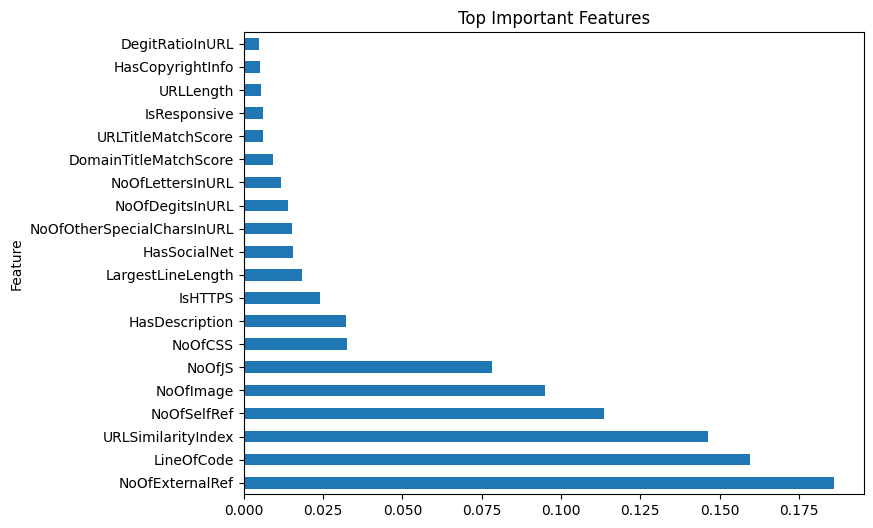

In [5]:

importance=pd.DataFrame({
'Feature':X.columns,
'Importance':model.feature_importances_
}).sort_values(
'Importance',
ascending=False
)

display(importance.head(20))

importance.head(20).plot.barh(
x='Feature',
y='Importance',
figsize=(8,6),
legend=False,
title="Top Important Features"
)
plt.show()


## Risk Score

In [6]:

def calculate_risk(probability):

    score=int(probability*100)

    if score<=20:
        level="Very Safe"

    elif score<=40:
        level="Low Risk"

    elif score<=60:
        level="Medium Risk"

    elif score<=80:
        level="High Risk"

    else:
        level="Critical"

    return score,level


## Human Readable Reasons

In [7]:

def generate_reasons(features):

    reasons=[]

    if 'IsHTTPS' in features.index:
        if features['IsHTTPS']==0:
            reasons.append("HTTPS is not enabled.")

    if 'URLLength' in features.index:
        if features['URLLength']>80:
            reasons.append("URL length is unusually high.")

    if 'NoOfPopup' in features.index:
        if features['NoOfPopup']>0:
            reasons.append("Website contains popup windows.")

    if 'HasPasswordField' in features.index:
        if features['HasPasswordField']==1:
            reasons.append("Password field detected.")

    if 'HasHiddenFields' in features.index:
        if features['HasHiddenFields']==1:
            reasons.append("Hidden HTML fields detected.")

    if len(reasons)==0:
        reasons.append("No major suspicious indicators detected.")

    return reasons


## Deployment Ready Prediction Function

In [8]:

def predict_sample(sample_row):

    # Scale the input row using the preprocessor
    sample_scaled = preprocessor.transform(sample_row.values.reshape(1, -1))

    probability=model.predict_proba(
        sample_scaled
    )[0][1]

    prediction=model.predict(
        sample_scaled
    )[0]

    score,level=calculate_risk(probability)

    reasons=generate_reasons(sample_row)

    return {
        "Prediction":"Phishing" if prediction==1 else "Legitimate",
        "Confidence":round(probability*100,2),
        "Risk Score":score,
        "Risk Level":level,
        "Reasons":reasons
    }


## Test on Dataset Samples

In [9]:

sample=X.iloc[0]

result=predict_sample(sample)

result


{'Prediction': 'Phishing',
 'Confidence': np.float64(99.97),
 'Risk Score': 99,
 'Risk Level': 'Critical',
 'Reasons': ['Hidden HTML fields detected.']}

## Test Multiple Samples

In [10]:

for i in range(5):

    print("="*70)

    print("Sample",i)

    print(predict_sample(X.iloc[i]))


Sample 0
{'Prediction': 'Phishing', 'Confidence': np.float64(99.97), 'Risk Score': 99, 'Risk Level': 'Critical', 'Reasons': ['Hidden HTML fields detected.']}
Sample 1
{'Prediction': 'Phishing', 'Confidence': np.float64(99.98), 'Risk Score': 99, 'Risk Level': 'Critical', 'Reasons': ['No major suspicious indicators detected.']}
Sample 2
{'Prediction': 'Phishing', 'Confidence': np.float64(99.98), 'Risk Score': 99, 'Risk Level': 'Critical', 'Reasons': ['Hidden HTML fields detected.']}
Sample 3
{'Prediction': 'Phishing', 'Confidence': np.float64(99.98), 'Risk Score': 99, 'Risk Level': 'Critical', 'Reasons': ['Website contains popup windows.', 'Hidden HTML fields detected.']}
Sample 4
{'Prediction': 'Phishing', 'Confidence': np.float64(99.98), 'Risk Score': 99, 'Risk Level': 'Critical', 'Reasons': ['Hidden HTML fields detected.']}


## Save Deployment Pipeline

In [11]:

joblib.dump(model,"deployment_model.pkl")

joblib.dump(list(X.columns),
            "deployment_features.pkl")

print("Deployment Files Saved")


Deployment Files Saved



# Final Project Output

The deployment function returns:

```python
{
    "Prediction":"Phishing",
    "Confidence":98.42,
    "Risk Score":96,
    "Risk Level":"Critical",
    "Reasons":[
        "HTTPS is not enabled.",
        "Password field detected.",
        "Website contains popup windows."
    ]
}
```

This output can be consumed directly by:

- FastAPI Backend
- React Web Application
- Chrome Extension

The browser extension can display:

- Prediction
- Confidence
- Risk Score
- Risk Level
- Human-readable reasons

making the system suitable for real-time phishing detection.
